# Predictive Analytics: Deep Neural Network (Resolution 8)

In [1]:
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import h3

In [2]:
print(torch.cuda.is_available())
print(torch.__version__)

True
2.6.0+cu124


In [3]:
## Import the data-splits:
df_train = pd.read_parquet("../data/prediction_split/res_8/df_train.parquet")
df_val = pd.read_parquet("../data/prediction_split/res_8/df_val.parquet")
df_test = pd.read_parquet("../data/prediction_split/res_8/df_test.parquet")
print(f"Train split loaded. Shape: {df_train.shape}")
print(f"Validation split loaded. Shape: {df_val.shape}")
print(f"Test split loaded. Shape: {df_test.shape}")

Train split loaded. Shape: (4641696, 53)
Validation split loaded. Shape: (1852320, 53)
Test split loaded. Shape: (2778934, 53)


In [4]:
# Derive cell-centroid lat/lon from the H3 index for every split.
# The original PickupLatitude/Longitude were per-hour *trip* averages and are
# undefined for the 97% of zero-demand hours, so they can"t locate empty hexagons.
# h3.cell_to_latlng() gives a stable centroid for every cell regardless of demand.
def add_cell_centroids(df):
    latlng = df["h3_index"].map(h3.cell_to_latlng)
    df["lat"] = latlng.map(lambda x: x[0])
    df["lon"] = latlng.map(lambda x: x[1])
    return df


for _df in (df_train, df_val, df_test):
    add_cell_centroids(_df)

print("Added lat/lon centroids. Train lat range:",
      f"[{df_train["lat"].min():.4f}, {df_train["lat"].max():.4f}], "
      f"lon range: [{df_train["lon"].min():.4f}, {df_train["lon"].max():.4f}]")

Added lat/lon centroids. Train lat range: [41.6501, 42.0198], lon range: [-87.9049, -87.5291]


In [5]:
## Preparing the data for training the Deep NN:
target = "Total_Trip_Start"  # Assuming this is the target variable in the dataset
features = [
    "lat", "lon",
    "scikit_distance_to_loop",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_of_week", "is_weekend", "is_holiday", "is_near_holiday",
    "2m_temp_c", "total_precip_mm", "snow_cov", "snow_depth", "wind_speed",
    "poi_cat_automotive", "poi_cat_civic_community", "poi_cat_education",
    "poi_cat_entertainment", "poi_cat_finance", "poi_cat_food_drink",
    "poi_cat_grocery", "poi_cat_health", "poi_cat_leisure_sports",
    "poi_cat_lodging", "poi_cat_nightlife", "poi_cat_services",
    "poi_cat_shopping", "poi_cat_transport"
]

# Scaling
# FOR Y-SPLIT:
# We use the log1p instead of standardscaler to compensate the influence of high-demand outliers on the loss
x_scaler = StandardScaler()
x_scaler.fit(df_train[features])

X_train_scaled = x_scaler.transform(df_train[features])
y_train = df_train[target].values
y_train_scaled = np.log1p(y_train)

X_val_scaled = x_scaler.transform(df_val[features])
y_val = df_val[target].values
y_val_scaled = np.log1p(y_val)

X_test_scaled = x_scaler.transform(df_test[features])
y_test = df_test[target].values
y_test_scaled = np.log1p(y_test)

# Convert the numpy arrays into tensors:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# Create tensor datasets, so we can then use them for our DataLoaders
train_set = TensorDataset(X_train_t, y_train_t)
validation_set = TensorDataset(X_val_t, y_val_t)
test_set = TensorDataset(X_test_t, y_test_t)

# Create the DataLoaders:
batch = 250
train_loader = DataLoader(train_set, batch_size=batch, shuffle=True) # shuffle to ensure varied batches across epochs
validation_loader = DataLoader(validation_set, batch_size=batch, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch, shuffle=False)



In [6]:
## Definition of a hyperparameter grid:
learning_rate_variants = [0.01, 0.001, 0.0001]
hidden_layer_variants = [[32, 16, 8 ],  [64, 32, 16],[128, 64, 32], [128, 64, 32, 16], [256, 128, 64, 32]]
input_layer = len(features) # Number of features
epochs = 10 # Note: We use early stopping

In [7]:
# Definition of the feedforward NN:
# Notes: We make the number of hidden layers with the number of neurons dynamic, so we can try out different complexities in our grid-search
class FNN(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super(FNN, self).__init__()
        self.layers = nn.ModuleList()
        prev_size = input_size
        for hidden_size in hidden_layers:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            prev_size = hidden_size

        self.output_layer = nn.Linear(prev_size, 1)

    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.output_layer(x).squeeze(1)


In [ ]:
# Definition of the training loop:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(device)

def train_model(FNN, device, train_loader, optimizer, loss_funct, epochs):
    FNN.train()
    loss_total = 0.0
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = FNN(inputs)
        loss = loss_funct(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()
        running_loss += loss.item()
        if(i+1) % 250 == 0:
            print(f"TRAINING Epoch {epochs}, Batch {i+1}, Loss: {running_loss / 250}")
            running_loss = 0.0
    loss_avg = loss_total / len(train_loader)
    print(f"TRAINING Epoch {epochs}, Loss: {loss_avg}")
    return loss_avg



cuda


In [9]:
def validate_model(FNN, device, validation_loader, loss_funct):
    print(f" Predicting on Validation...")
    FNN.eval()
    loss_total = 0.0
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = FNN(inputs)
            loss = loss_funct(outputs, labels)
            loss_total += loss.item()
    loss_avg = loss_total / len(validation_loader)
    print(f"VALIDATION, Loss: {loss_avg}")
    return loss_avg


In [10]:
# Grid-search for each hyperparameter combination defined before.
# Train the model for each batch in one epoch and validate the model after each epoch on the validation set
# We use early stopping, so we can make model training more efficient. Otherwise, we would train models long after they started overfitting

from IPython.display import clear_output, display ## Use: clear the output cell -> print out the results_df

loss_funct = nn.MSELoss()
results_df = pd.DataFrame(columns=["config", "layers", "lr", "epoch", "train_loss", "val_loss"]) #To save the train/val losses per configuration
# Number of epochs we wait until our early stop applies
max_epochs_without_improvement = 3
for hidden_variant in hidden_layer_variants:
    for learning_rate in learning_rate_variants:
        config_name = f"layers={hidden_variant}_lr={learning_rate}"
        model = FNN(input_layer, hidden_variant).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate) #Adam is much more stable compared to SGD
        
        epochs_without_improvement = 0
        best_val_loss = None     

        for epoch_index in range(1, epochs+1):
            print(f"\n########### Training: {config_name} ###########")
            train_loss = train_model(model, device, train_loader, optimizer, loss_funct, epoch_index)
            val_loss = validate_model(model, device, validation_loader, loss_funct)

            if best_val_loss is None or val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0  
                torch.save(model.state_dict(), f"../models/grid_search_models/res8_best_{config_name}.pth")
            else:
                epochs_without_improvement += 1

            results_df.loc[len(results_df)] = {
                "config": config_name,
                "layers": str(hidden_variant),
                "lr": learning_rate,
                "epoch": epoch_index,
                "train_loss": train_loss,
                "val_loss": val_loss
            }

            clear_output(wait=True) # clears the output-cell
            display(results_df.set_index(["config", "epoch"]))  # nicer presentation of the training progress
            
            if epochs_without_improvement >= max_epochs_without_improvement:
                print(f"Early stopping at epoch {epoch_index} for {config_name}")
                break


layers      lr  \
config                              epoch                               
layers=[32, 16, 8]_lr=0.01          1             [32, 16, 8]  0.0100   
                                    2             [32, 16, 8]  0.0100   
                                    3             [32, 16, 8]  0.0100   
                                    4             [32, 16, 8]  0.0100   
                                    5             [32, 16, 8]  0.0100   
...                                                       ...     ...   
layers=[256, 128, 64, 32]_lr=0.0001 6      [256, 128, 64, 32]  0.0001   
                                    7      [256, 128, 64, 32]  0.0001   
                                    8      [256, 128, 64, 32]  0.0001   
                                    9      [256, 128, 64, 32]  0.0001   
                                    10     [256, 128, 64, 32]  0.0001   

                                           train_loss  val_loss  
config                              epoch                        
layers=[32, 16, 8]_lr=0.01          1        0.028414  0.032598  
                                    2        0.022705  0.028557  
                                    3        0.021896  0.028915  
                                    4        0.021478  0.034371  
                                    5        0.021240  0.029600  
...                                               ...       ...  
layers=[256, 128, 64, 32]_lr=0.0001 6        0.017602  0.026195  
                                    7        0.017168  0.023408  
                                    8        0.016792  0.023218  
                                    9        0.016393  0.024415  
                                    10       0.016056  0.023292  

[125 rows x 4 columns]

In [11]:
print(results_df)

                                  config              layers      lr  epoch  \
0             layers=[32, 16, 8]_lr=0.01         [32, 16, 8]  0.0100      1   
1             layers=[32, 16, 8]_lr=0.01         [32, 16, 8]  0.0100      2   
2             layers=[32, 16, 8]_lr=0.01         [32, 16, 8]  0.0100      3   
3             layers=[32, 16, 8]_lr=0.01         [32, 16, 8]  0.0100      4   
4             layers=[32, 16, 8]_lr=0.01         [32, 16, 8]  0.0100      5   
..                                   ...                 ...     ...    ...   
120  layers=[256, 128, 64, 32]_lr=0.0001  [256, 128, 64, 32]  0.0001      6   
121  layers=[256, 128, 64, 32]_lr=0.0001  [256, 128, 64, 32]  0.0001      7   
122  layers=[256, 128, 64, 32]_lr=0.0001  [256, 128, 64, 32]  0.0001      8   
123  layers=[256, 128, 64, 32]_lr=0.0001  [256, 128, 64, 32]  0.0001      9   
124  layers=[256, 128, 64, 32]_lr=0.0001  [256, 128, 64, 32]  0.0001     10   

     train_loss  val_loss  
0      0.028414  0.0325

In [14]:
# For each config, load its best model and compute the val MAE in normal space (not in the log1 space)
val_maes = {}
for config_name in results_df["config"].unique():
    layers = eval(results_df[results_df["config"] == config_name]["layers"].iloc[0])
    m = FNN(input_layer, layers).to(device)
    m.load_state_dict(torch.load(f"../models/grid_search_models/res8_best_{config_name}.pth", map_location=device))
    m.eval()
    with torch.no_grad():
        val_preds = np.clip(np.expm1(m(X_val_t.to(device)).cpu().numpy()), 0, None)
    val_maes[config_name] = mean_absolute_error(y_val, val_preds)
    print(f"{config_name}: val MAE = {val_maes[config_name]:.4f}")

best_config = min(val_maes, key=val_maes.get)
best_layers = eval(results_df[results_df["config"] == best_config]["layers"].iloc[0])
print(f"\nBest config: {best_config}, val MAE: {val_maes[best_config]:.4f}")

# Save the best model predictions and the respective config name
model = FNN(input_layer, best_layers).to(device)
model.load_state_dict(torch.load(f"../models/grid_search_models/res8_best_{best_config}.pth", map_location=device))
model.eval()

torch.save(model.state_dict(), f"../models/best_fnn_res8_{best_config}.pth")

layers=[32, 16, 8]_lr=0.01: val MAE = 0.3106
layers=[32, 16, 8]_lr=0.001: val MAE = 0.2793
layers=[32, 16, 8]_lr=0.0001: val MAE = 0.2961
layers=[64, 32, 16]_lr=0.01: val MAE = 0.3495
layers=[64, 32, 16]_lr=0.001: val MAE = 0.2632
layers=[64, 32, 16]_lr=0.0001: val MAE = 0.2743
layers=[128, 64, 32]_lr=0.01: val MAE = 0.3310
layers=[128, 64, 32]_lr=0.001: val MAE = 0.2677
layers=[128, 64, 32]_lr=0.0001: val MAE = 0.2628
layers=[128, 64, 32, 16]_lr=0.01: val MAE = 0.3226
layers=[128, 64, 32, 16]_lr=0.001: val MAE = 0.2544
layers=[128, 64, 32, 16]_lr=0.0001: val MAE = 0.2642
layers=[256, 128, 64, 32]_lr=0.01: val MAE = 0.3471
layers=[256, 128, 64, 32]_lr=0.001: val MAE = 0.2731
layers=[256, 128, 64, 32]_lr=0.0001: val MAE = 0.2778

Best config: layers=[128, 64, 32, 16]_lr=0.001, val MAE: 0.2544


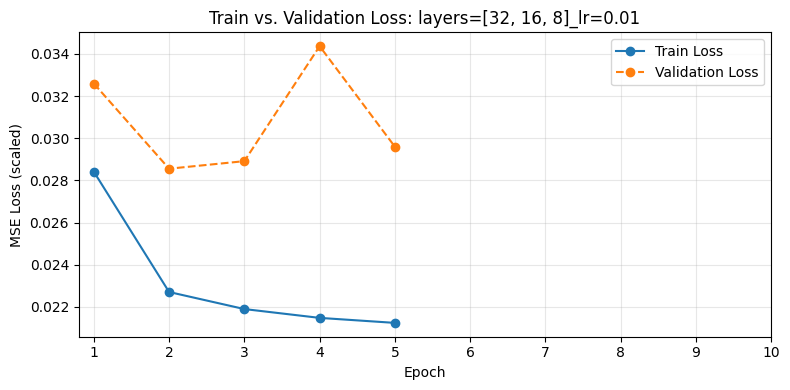

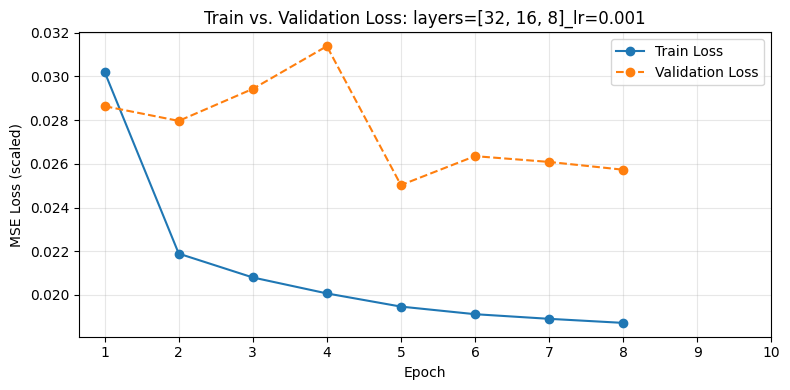

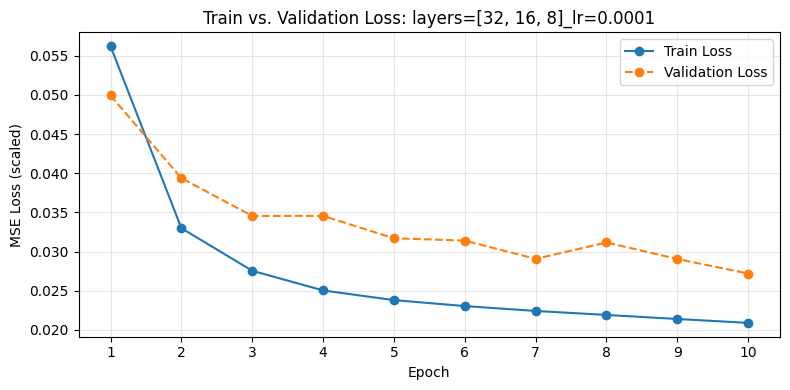

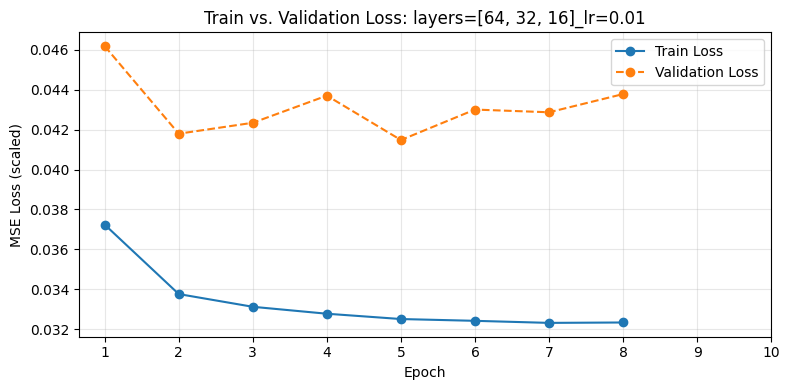

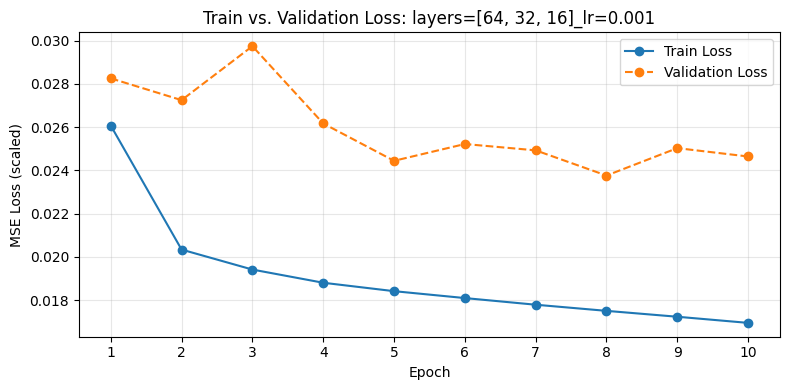

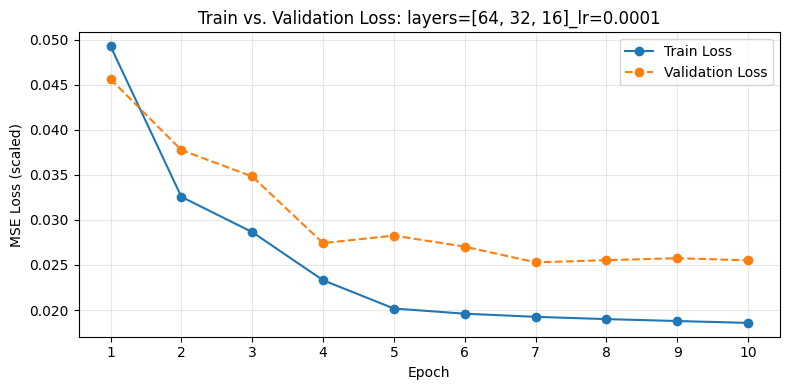

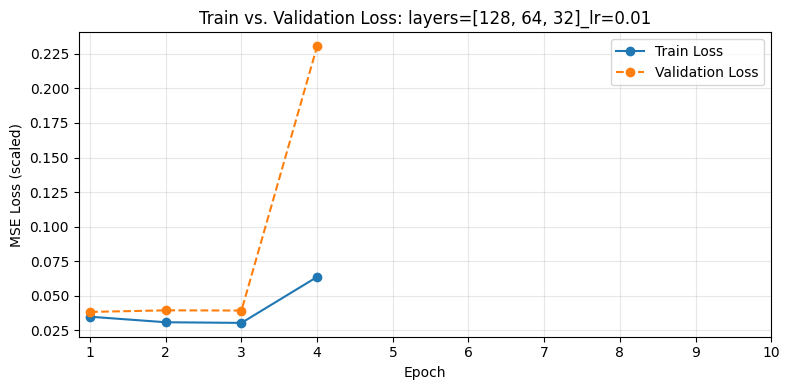

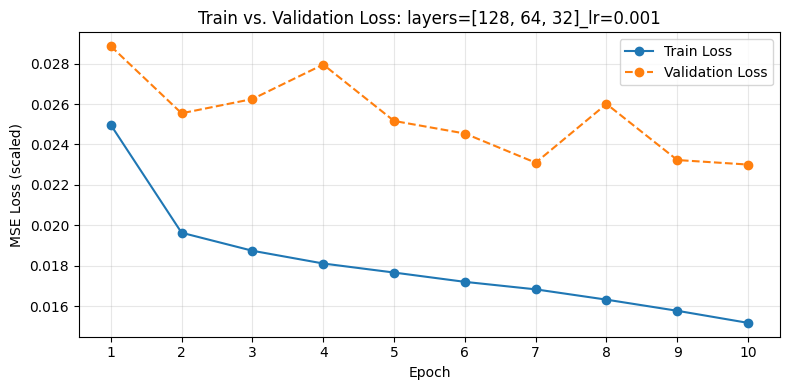

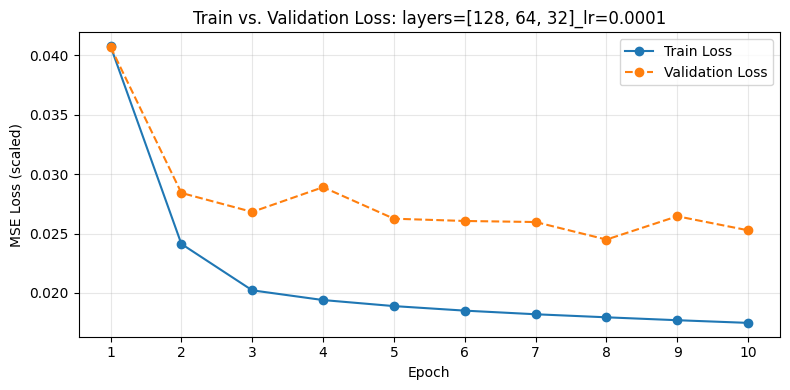

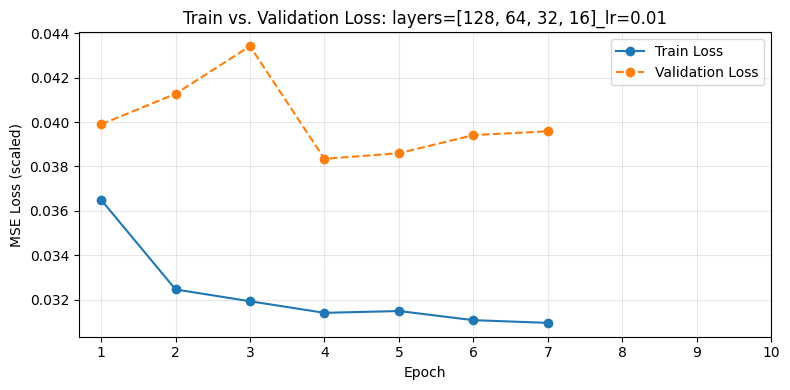

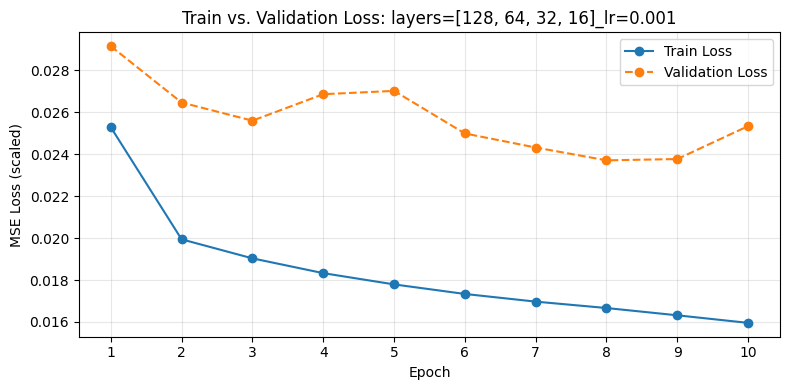

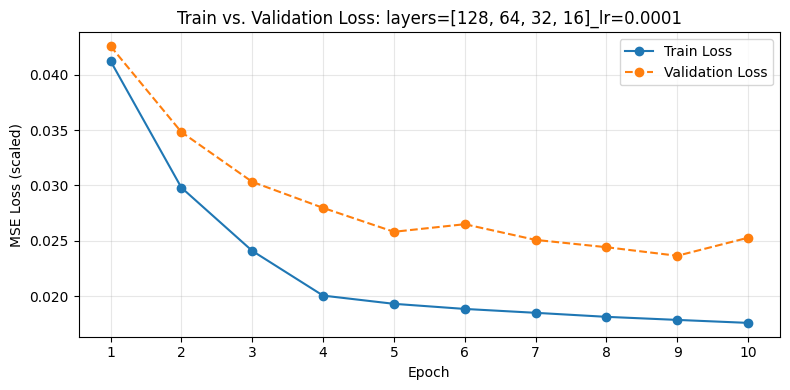

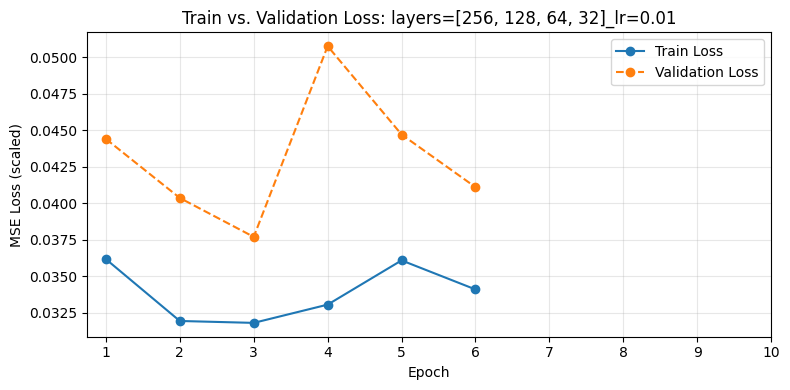

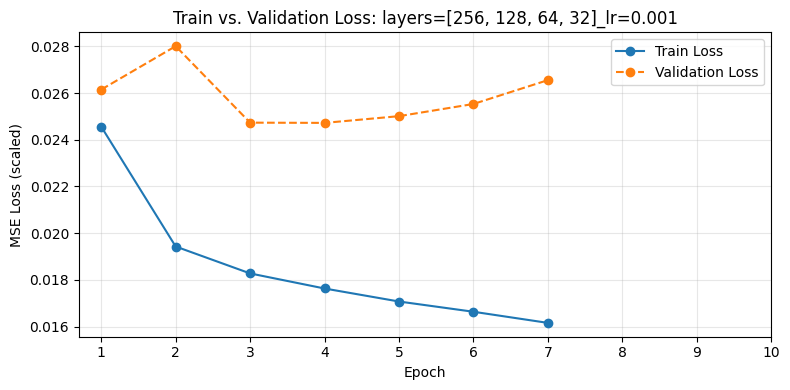

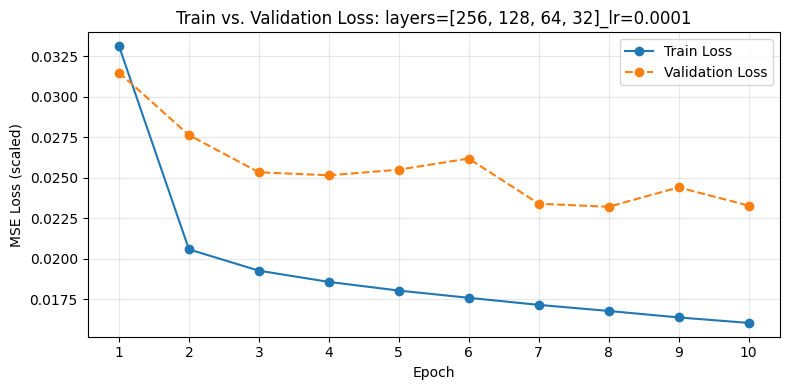

In [15]:
## Visualization of the trained NNs during grid search
for config_name in results_df["config"].unique():
    group = results_df[results_df["config"] == config_name]
    plt.figure(figsize=(8, 4))
    plt.plot(group["epoch"], group["train_loss"], label="Train Loss", marker="o")
    plt.plot(group["epoch"], group["val_loss"], label="Validation Loss", marker="o", linestyle="--")
    plt.title(f"Train vs. Validation Loss: {config_name}")
    plt.xlabel("Epoch")
    plt.xticks(range(1, epochs + 1))
    plt.ylabel("MSE Loss (scaled)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"../plots/learning_curve_res8_{config_name}.png", dpi=150)
    plt.show()


In [ ]:
# # Visualization of the prediction on the actual data (Validation and Test splits)
# # Also: Calculate the MAE, R2 and RMSE on Validation and Test (written in the plot title)
# for layers in hidden_layer_variants:
#     for lr in learning_rate_variants:
#         config = f"layers={layers}_lr={lr}"

#         model = FNN(input_layer, layers).to(device)
#         model.load_state_dict(torch.load(f"../plots/best_{config}.pth", map_location=device))
#         model.eval()

#         with torch.no_grad():
#             val_preds = np.clip(np.expm1(model(X_val_t.to(device)).cpu().numpy()), 0, None)
#             test_preds = np.clip(np.expm1(model(X_test_t.to(device)).cpu().numpy()), 0, None)

#         val_preds = np.clip(val_preds, 0, None)
#         test_preds = np.clip(test_preds, 0, None)

#         df_val["predicted"] = val_preds
#         df_test["predicted"] = test_preds

#         for df, split, preds in [(df_val, "Validation", val_preds), (df_test, "Test", test_preds)]:
#             mae = mean_absolute_error(df["Total_Trip_Start"], preds)
#             rmse = np.sqrt(mean_squared_error(df["Total_Trip_Start"], preds))
#             r2   = r2_score(df["Total_Trip_Start"], preds)


#             actual = df.groupby("hour")["Total_Trip_Start"].sum()
#             predicted = df.groupby("hour")["predicted"].sum()

#             plt.figure(figsize=(14, 4))
#             plt.plot(actual.index, actual.values, linewidth=0.7, label=f"Actual ({split})")
#             plt.plot(predicted.index, predicted.values, linewidth=0.7, label=f"Predicted ({split})", linestyle="--")
#             plt.title(f"{split} | {config} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}")
#             plt.xlabel("Hour")
#             plt.ylabel("Total Trip Starts")
#             plt.legend()
#             plt.tight_layout()
#             plt.savefig(f"../plots/{split.lower()}_{config}.png", dpi=150)
#             plt.close()

In [ ]:
# ### EXPERIMENTAL: Also include a scatter plot, that checks the prediction vs true value for each hexagon with a trip above 0
# ### Why only rows for hexagons above zero? Because the loss function is "too optimistic" due to the large number of zero-columns. Our model is actually underpredicting values above zero
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# for layers in hidden_layer_variants:
#     for lr in learning_rate_variants:
#         config = f"layers={layers}_lr={lr}"

#         model = FNN(input_layer, layers).to(device)
#         model.load_state_dict(torch.load(f"../plots/best_{config}.pth", map_location=device))
#         model.eval()

#         with torch.no_grad():
#             val_preds = np.clip(np.expm1(model(X_val_t.to(device)).cpu().numpy()), 0, None)
#             test_preds = np.clip(np.expm1(model(X_test_t.to(device)).cpu().numpy()), 0, None)

#         val_preds = np.clip(val_preds, 0, None)
#         test_preds = np.clip(test_preds, 0, None)

#         df_val["predicted"] = val_preds
#         df_test["predicted"] = test_preds

#         for df, split, preds in [(df_val, "Validation", val_preds), (df_test, "Test", test_preds)]:
#             mae_all = mean_absolute_error(df["Total_Trip_Start"], preds)
#             rmse_all = np.sqrt(mean_squared_error(df["Total_Trip_Start"], preds))
#             r2   = r2_score(df["Total_Trip_Start"], preds)


#             # metrics only where actual demand > 0, since zeros dominate the overall MAE
#             active = df["Total_Trip_Start"] > 0
#             mae_active = mean_absolute_error(df.loc[active, "Total_Trip_Start"], preds[active.values])
#             rmse_active = np.sqrt(mean_squared_error(df.loc[active, "Total_Trip_Start"], preds[active.values]))

#             fig, axes = plt.subplots(1, 2, figsize=(18, 5))
#             fig.suptitle(f"{split} | {config}", fontsize=13)

#             # city-level aggregate over time
#             actual_agg = df.groupby("hour")["Total_Trip_Start"].sum()
#             predicted_agg = df.groupby("hour")["predicted"].sum()
#             axes[0].plot(actual_agg.index, actual_agg.values, linewidth=0.7, label="Actual")
#             axes[0].plot(predicted_agg.index, predicted_agg.values, linewidth=0.7, label="Predicted", linestyle="--")
#             axes[0].set_title(f"City-level Aggregate\nMAE: {mae_all:.2f} | RMSE: {rmse_all:.2f} | R²: {r2:.4f}")
#             axes[0].set_xlabel("Hour")
#             axes[0].set_ylabel("Total Trip Starts (summed over all hexagons)")
#             axes[0].legend(loc="upper left")

#             # scatter plot per hexagon * hour (only where demand > 0)
#             x_max = df.loc[active, "Total_Trip_Start"].quantile(0.99)
#             axes[1].scatter(df.loc[active, "Total_Trip_Start"], preds[active.values], alpha=0.1, s=2, color="steelblue")
#             axes[1].plot([0, x_max], [0, x_max], "r--", linewidth=1, label="Perfect prediction")
#             axes[1].set_xlim(0, x_max)
#             axes[1].set_ylim(0, x_max)
#             axes[1].set_title(f"Actual vs. Predicted per Hexagon * Hour\nMAE (active only): {mae_active:.2f} | RMSE (active only): {rmse_active:.2f}")
#             axes[1].set_xlabel("Actual Trip Starts")
#             axes[1].set_ylabel("Predicted Trip Starts")
#             axes[1].legend(loc="upper left")

#             plt.tight_layout()
#             plt.savefig(f"../plots/{split.lower()}_{config}.png", dpi=150)
#             plt.close()